In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors  import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [2]:
df=pd.read_csv("house_price_regression_dataset.csv")

In [3]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [4]:
df.shape

(1000, 8)

In [5]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [7]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [8]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [9]:
df["House_Price"]=df["House_Price"].round(4)

In [10]:
columns=[
    "Square_Footage",
    "Num_Bedrooms",
    "Num_Bathrooms",
    "Year_Built",
    "Lot_Size",
    "Garage_Size",
    "Neighborhood_Quality",
]

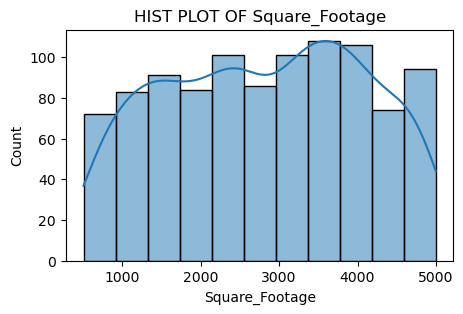

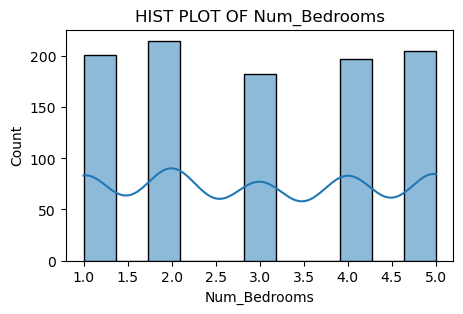

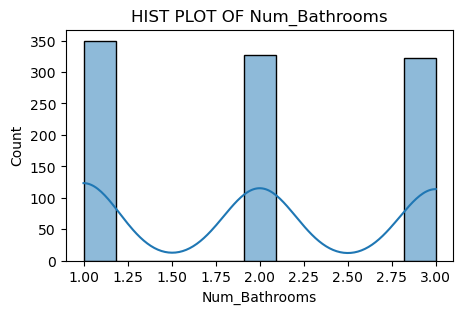

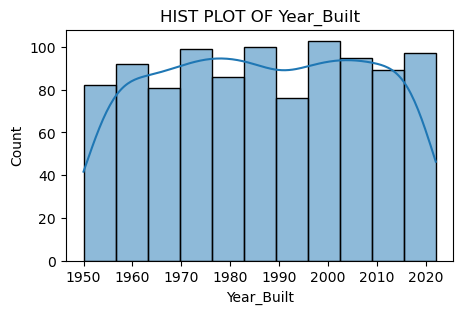

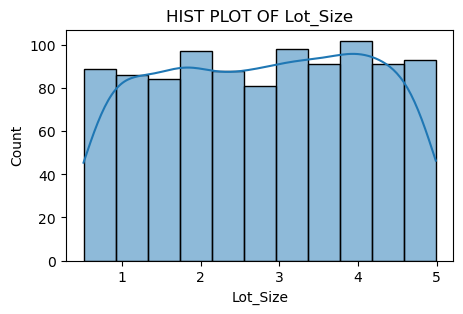

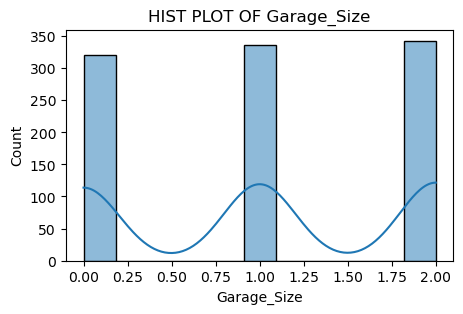

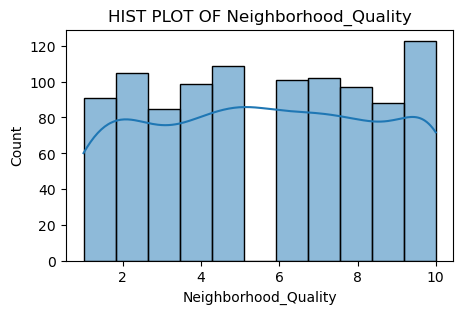

In [11]:
for col in columns:
    plt.figure(figsize=(5,3))
    sns.histplot(
        data=df[col],
        kde=True
    )
    plt.title(f"HIST PLOT OF {col}")
    plt.show()

In [12]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

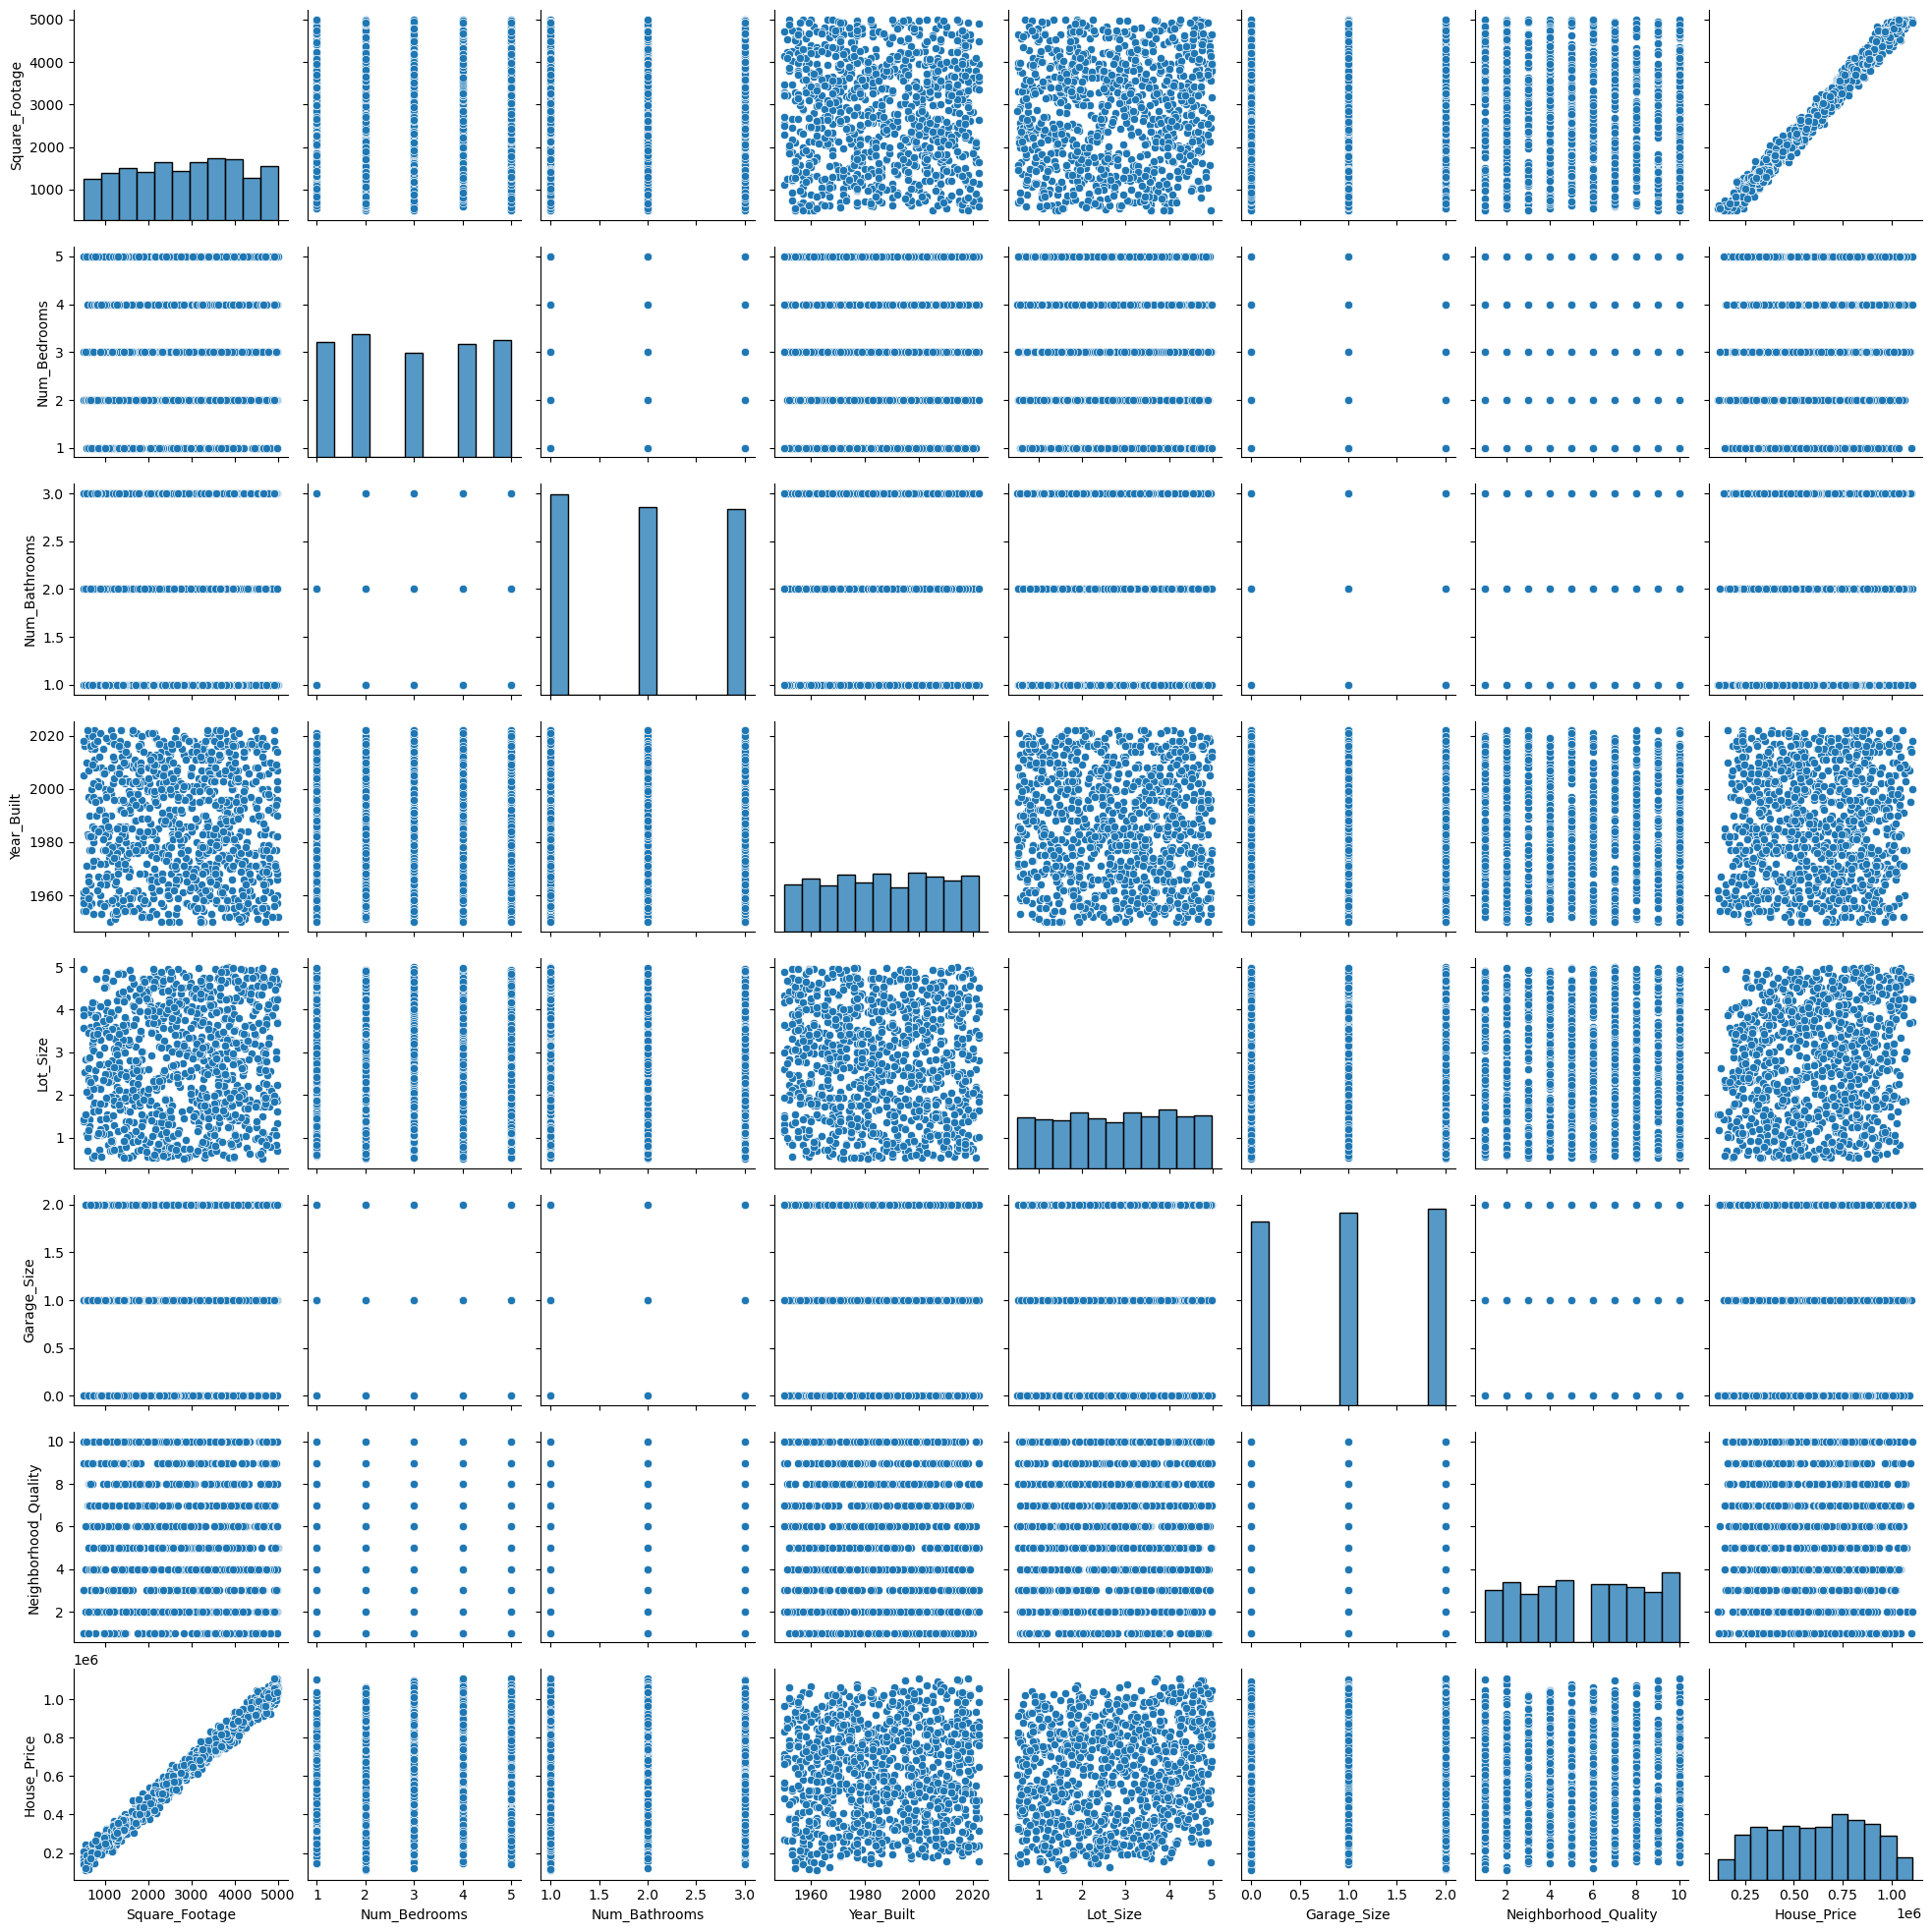

In [13]:
sns.pairplot(df)
plt.show()

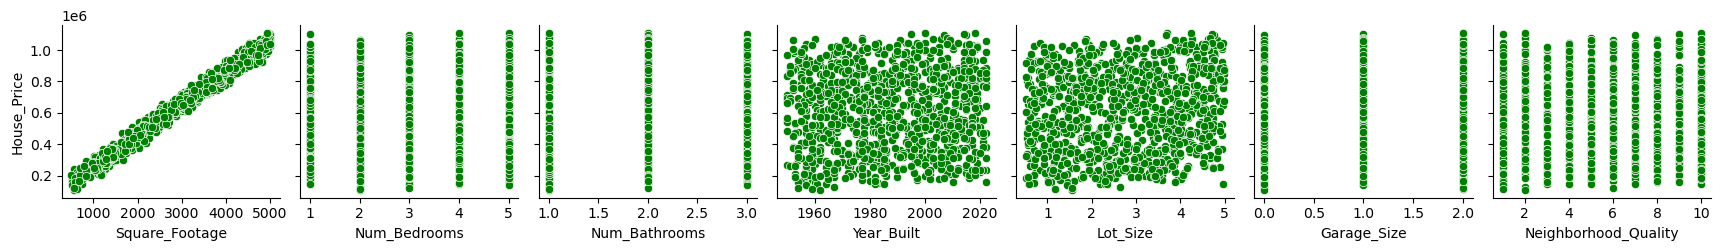

In [14]:
sns.pairplot(
    df,y_vars=["House_Price"],
    x_vars=df.columns[:-1],plot_kws={"color":"green"}
)
plt.show()

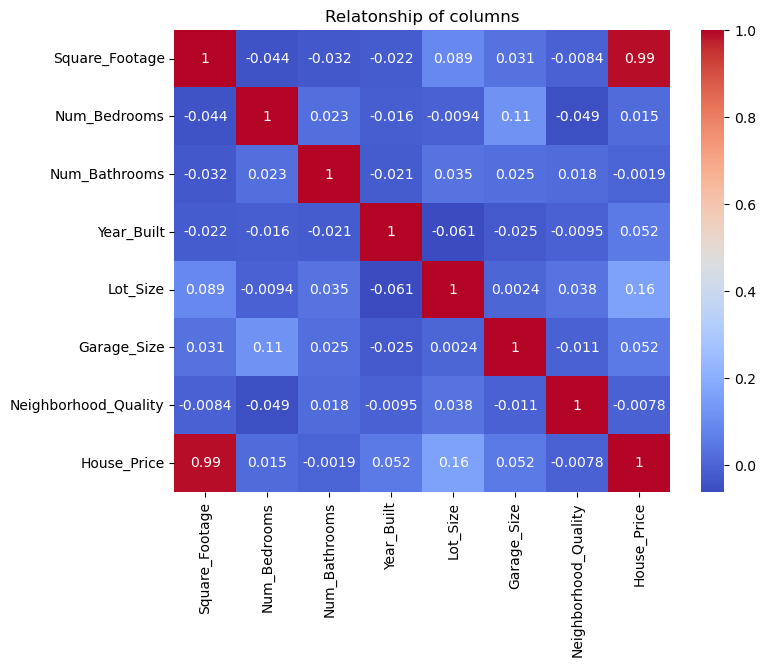

<Figure size 640x480 with 0 Axes>

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(
    data=df.corr(numeric_only=True),annot=True,cmap="coolwarm"
)
plt.title("Relatonship of columns")
plt.show()
plt.tight_layout()

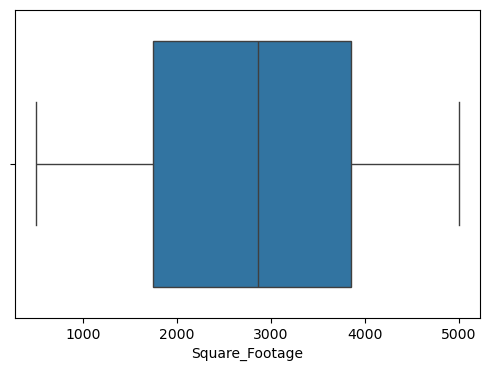

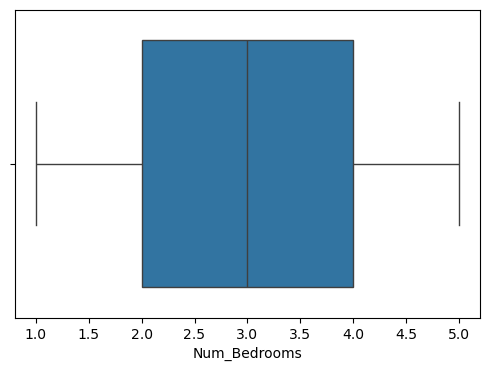

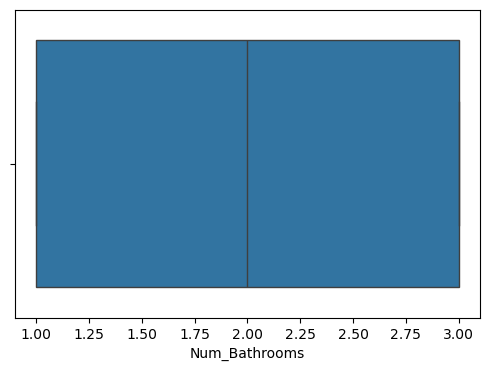

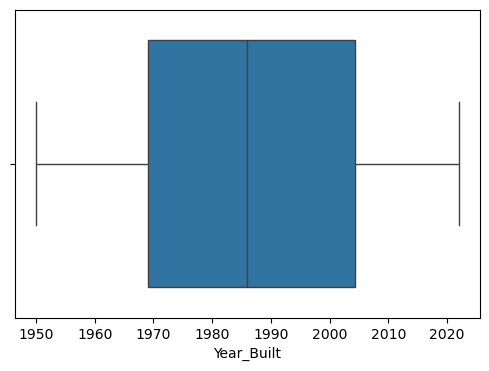

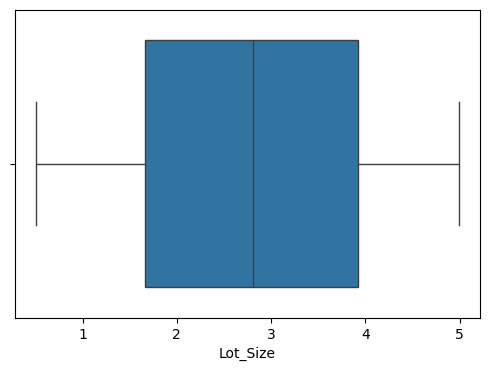

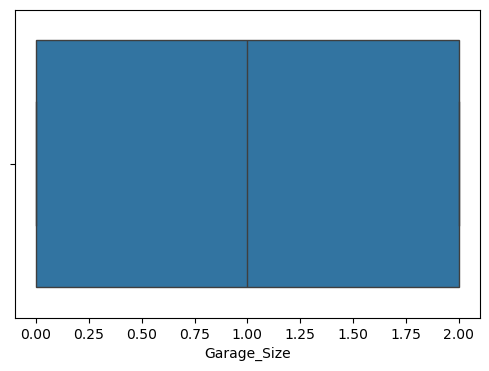

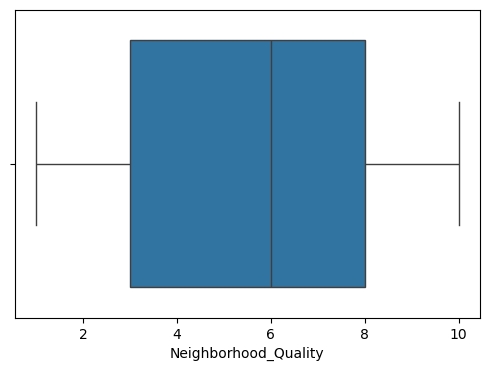

In [16]:
for col in columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(
    x=df[col]

)

plt.show()

In [17]:
X=df.drop("House_Price",axis=1)

In [18]:
y=df["House_Price"]

In [19]:
X.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0.599637,0,5
1,4272,3,3,2016,4.753014,1,6
2,3592,1,2,2016,3.634823,0,9
3,966,1,2,1977,2.730667,1,8
4,4926,2,1,1993,4.699073,0,8


In [20]:
y.head()

0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64

In [21]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [22]:
X_train.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
29,2028,2,3,1967,1.784790,2,2
535,3519,5,3,1966,4.009947,0,10
695,4507,2,3,2014,4.122337,0,7
557,3371,4,2,2000,1.580318,0,1
836,2871,5,1,1974,3.426914,2,6


In [23]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [24]:
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)
y_pred_lr=lr_model.predict(X_test)
mae_lr=mean_absolute_error(y_test,y_pred_lr)

In [25]:
mae_lr

8174.583598016298

In [26]:
mse_lr=mean_squared_error(y_test,y_pred_lr)

In [27]:
mse_lr

101434798.47488892

In [28]:
r2_score_lr=r2_score(y_test,y_pred_lr
                    )

In [29]:
r2_score_lr

0.9984263636828057

In [30]:
knn_model=KNeighborsRegressor(n_neighbors=7,weights="uniform")
knn_model.fit(X_train_scaled,y_train)
y_pred_knn=knn_model.predict(X_test_scaled)
mae_knn=mean_absolute_error(y_test,y_pred_knn)
mae_knn

66318.55541685715

In [31]:
mse_knn=mean_squared_error(y_test,y_pred_knn)

In [32]:
mse_knn

6772782074.252371

In [33]:
r2_score_knn=r2_score(y_test,y_pred_knn)

In [34]:
r2_score_knn

0.894928604377083

In [35]:
dt_model=DecisionTreeRegressor()
dt_model.fit(X_train,y_train)
y_pred_dt=dt_model.predict(X_test)
mae_dt=mean_absolute_error(y_test,y_pred_dt)
mae_dt

25243.257645000005

In [36]:
mse_dt=mean_squared_error(y_test,y_pred_dt)

In [37]:
mse_dt

1065475628.050867

In [38]:
r2_score_dt=r2_score(y_test,y_pred_dt)

In [39]:
r2_score_dt

0.9834704542366562

In [40]:
rf_model=RandomForestRegressor()
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
mae_rf=mean_absolute_error(y_test,y_pred_rf)
mae_rf

16048.399237209991

In [41]:
mse_rf=mean_squared_error(y_test,y_pred_rf)
mse_rf

388684759.6666799

In [42]:
r2_score_rf=r2_score(y_test,y_pred_rf)
r2_score_rf

0.9939700333322707

In [43]:
gb_model=GradientBoostingRegressor()
gb_model.fit(X_train,y_train)
y_pred_gb=gb_model.predict(X_test)
mae_gb=mean_absolute_error(y_test,y_pred_gb)
mae_gb

12307.411765863606

In [44]:
mse_gb=mean_squared_error(y_test,y_pred_gb)
mse_gb

225021370.28841868

In [45]:
r2_score_gb=r2_score(y_test,y_pred_gb)
r2_score_gb

0.9965090698088355

In [46]:
svr_model=SVR(
    kernel="linear",
    C=1000,
    epsilon=0.1,
    
)
svr_model.fit(X_train_scaled,y_train)
y_pred_svr=svr_model.predict(X_test_scaled)
mae_svr=mean_absolute_error(y_test,y_pred_svr)
mae_svr

9379.073998580088

In [47]:
mse_svr=mean_squared_error(y_test,y_pred_svr)
mse_svr

130259096.18255514

In [48]:
r2_score_svr=r2_score(y_test,y_pred_svr)
r2_score_svr

0.997979190105568

In [49]:
results={
    "Linear Regression":[mae_lr,mse_lr,r2_score_lr],
    "KNN":[mae_knn,mse_knn,r2_score_knn],
    "Decision Tree":[mae_dt,mse_dt,r2_score_dt],
    "Random Forest":[mae_rf,mse_rf,r2_score_rf],
    "Gradient Boosting":[mae_gb,mse_gb,r2_score_gb],
    "SVR":[mae_svr,mse_svr,r2_score_svr]
}
results_df=pd.DataFrame(results,index=["MAE","MSE","R2"]).T
results_df

,MAE,MSE,R2
Linear Regression,8174.583598,1.014348e+08,0.998426
KNN,66318.555417,6.772782e+09,0.894929
Decision Tree,25243.257645,1.065476e+09,0.983470
Random Forest,16048.399237,3.886848e+08,0.993970
Gradient Boosting,12307.411766,2.250214e+08,0.996509
SVR,9379.073999,1.302591e+08,0.997979


In [50]:
results_df.sort_values("R2",ascending=False)

,MAE,MSE,R2
Linear Regression,8174.583598,1.014348e+08,0.998426
SVR,9379.073999,1.302591e+08,0.997979
Gradient Boosting,12307.411766,2.250214e+08,0.996509
Random Forest,16048.399237,3.886848e+08,0.993970
Decision Tree,25243.257645,1.065476e+09,0.983470
KNN,66318.555417,6.772782e+09,0.894929


In [51]:
best_model=lr_model

In [52]:
sample=X_test.iloc[[0]]
prediction=best_model.predict(sample)
prediction


array([868687.10747982])

In [53]:
print("Actual Price",y_test.iloc[0])
print("Predicted Price",prediction[0])

Actual Price 901000.4882
Predicted Price 868687.10747982


In [54]:
final_model=LinearRegression()
final_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
import joblib
joblib.dump(final_model,"house_price_prediction_model.pkl")
print("model saved successfully")

model saved successfully


In [56]:
joblib.dump(X.columns.to_list(),"features.pkl")

['features.pkl']

In [57]:
model=joblib.load("house_price_prediction_model.pkl")

In [58]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
features=joblib.load("features.pkl")

In [60]:
features

['Square_Footage',
 'Num_Bedrooms',
 'Num_Bathrooms',
 'Year_Built',
 'Lot_Size',
 'Garage_Size',
 'Neighborhood_Quality']